In [2]:
import pandas as pd


df = pd.read_parquet(
    "../../data/analytical/base_analitica_v1.parquet"
)

df.head()

,id_municipio,Municipio,UF,Capital,taxa_alfabetizacao_2023,percentual_participacao_2023,meta_alfabetizacao_2024,taxa_alfabetizacao_2024,Regiao,gap_meta_2024,target_atingiu_meta_2024
0,4301750,Barão do Triunfo,RS,Falso,NaN,NaN,NaN,4.40,Sul,NaN,0
1,2406908,Lucrécia,RN,Falso,4.4,82.14,7.94,42.86,Nordeste,3.54,1
2,1718501,Recursolândia,TO,Falso,4.6,95.65,8.25,50.29,Norte,3.65,1
3,2919900,Macururé,BA,Falso,4.7,87.76,8.39,12.50,Nordeste,3.69,1
4,2414456,Triunfo Potiguar,RN,Falso,NaN,NaN,NaN,10.95,Nordeste,NaN,0


In [3]:
df_modelo = df.dropna(subset=[
    "taxa_alfabetizacao_2023",
    "percentual_participacao_2023",
    "meta_alfabetizacao_2024",
    "taxa_alfabetizacao_2024"
]).copy()

features = [
    "taxa_alfabetizacao_2023",
    "percentual_participacao_2023",
    "meta_alfabetizacao_2024",
    "UF",
    "Capital"
]

target = "taxa_alfabetizacao_2024"

X = df_modelo[features]
y = df_modelo[target]

In [4]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

In [5]:
numeric_features = [
    "taxa_alfabetizacao_2023",
    "percentual_participacao_2023",
    "meta_alfabetizacao_2024"
]

categorical_features = [
    "UF",
    "Capital"
]

In [6]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

numeric_transformer_rf = Pipeline([
    ("imputer", SimpleImputer(strategy="median"))
])

categorical_transformer_rf = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor_rf = ColumnTransformer([
    ("num", numeric_transformer_rf, numeric_features),
    ("cat", categorical_transformer_rf, categorical_features)
])

In [7]:
from sklearn.ensemble import RandomForestRegressor

modelo_rf = Pipeline([
    ("preprocessor", preprocessor_rf),
    (
        "model",
        RandomForestRegressor(
            n_estimators=300,
            random_state=42,
            n_jobs=-1
        )
    )
])


modelo_rf.fit(
    X_train,
    y_train
)
y_pred_rf = modelo_rf.predict(X_test)

In [8]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

mae_rf = mean_absolute_error(
    y_test,
    y_pred_rf
)

rmse_rf = np.sqrt(
    mean_squared_error(
        y_test,
        y_pred_rf
    )
)

r2_rf = r2_score(
    y_test,
    y_pred_rf
)

print(f"MAE:  {mae_rf:.2f}")
print(f"RMSE: {rmse_rf:.2f}")
print(f"R²:   {r2_rf:.2f}")

MAE:  9.22
RMSE: 12.11
R²:   0.59


### Aplicação em regressão linear

In [9]:
from sklearn.linear_model import LinearRegression

modelo_linear = Pipeline([
    ("preprocessor", preprocessor_rf),
    ("model", LinearRegression())
])

In [10]:
modelo_linear.fit(
    X_train,
    y_train
)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](5,)","['taxa_alfabetizacao_2023','percentual_participacao_2023', 'meta_alfabetizacao_2024','UF','Capital']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,5
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed thro

In [11]:
y_pred_linear = modelo_linear.predict(X_test)

In [12]:
mae_linear = mean_absolute_error(
    y_test,
    y_pred_linear
)

rmse_linear = np.sqrt(
    mean_squared_error(
        y_test,
        y_pred_linear
    )
)

r2_linear = r2_score(
    y_test,
    y_pred_linear
)

print(f"MAE:  {mae_linear:.2f}")
print(f"RMSE: {rmse_linear:.2f}")
print(f"R²:   {r2_linear:.2f}")

MAE:  8.55
RMSE: 11.22
R²:   0.65


In [98]:
avaliacao = pd.DataFrame({
    "real": y_test,
    "previsto": y_pred_linear
})

avaliacao["erro"] = (
    avaliacao["real"] - avaliacao["previsto"]
)

avaliacao["erro_absoluto"] = (
    avaliacao["erro"].abs()
)

avaliacao.head(10)

,real,previsto,erro,erro_absoluto
257,39.30,36.130829,3.169171,3.169171
621,49.34,49.016805,0.323195,0.323195
2339,34.55,45.584625,-11.034625,11.034625
1487,64.82,70.616794,-5.796794,5.796794
1906,46.14,61.754998,-15.614998,15.614998
90,51.81,33.148547,18.661453,18.661453
3957,90.23,75.214680,15.015320,15.015320
1006,55.72,55.589187,0.130813,0.130813
4551,91.72,71.280473,20.439527,20.439527
1323,43.99,59.786877,-15.796877,15.796877


In [15]:
print(
    "Erro médio:",
    avaliacao["erro"].mean()
)

print(
    "Erro absoluto médio:",
    avaliacao["erro_absoluto"].mean()
)

Erro médio: -0.4395603856427065
Erro absoluto médio: 9.100788829565104


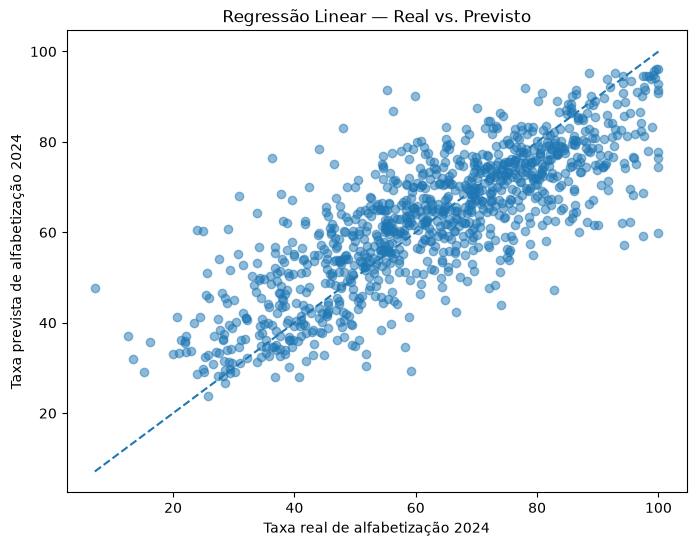

In [27]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))

plt.scatter(
    avaliacao["real"],
    avaliacao["previsto"],
    alpha=0.5
)

limite_min = min(
    avaliacao["real"].min(),
    avaliacao["previsto"].min()
)

limite_max = max(
    avaliacao["real"].max(),
    avaliacao["previsto"].max()
)

plt.plot(
    [limite_min, limite_max],
    [limite_min, limite_max],
    linestyle="--"
)

plt.xlabel("Taxa real de alfabetização 2024")
plt.ylabel("Taxa prevista de alfabetização 2024")
plt.title("Regressão Linear — Real vs. Previsto")

plt.show()

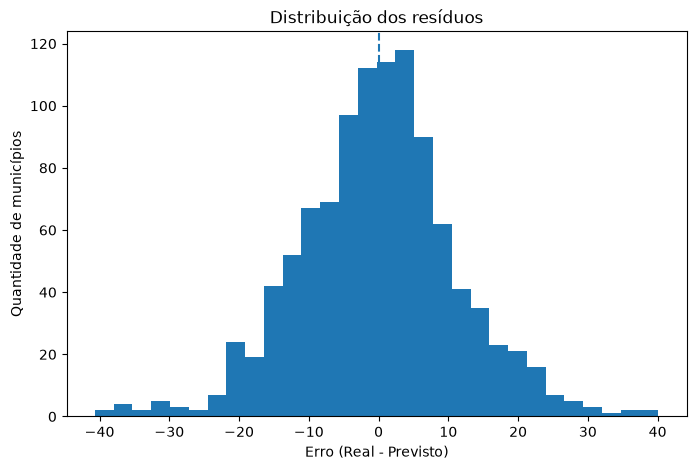

In [28]:
plt.figure(figsize=(8, 5))

plt.hist(
    avaliacao["erro"],
    bins=30
)

plt.axvline(
    0,
    linestyle="--"
)

plt.xlabel("Erro (Real - Previsto)")
plt.ylabel("Quantidade de municípios")
plt.title("Distribuição dos resíduos")

plt.show()

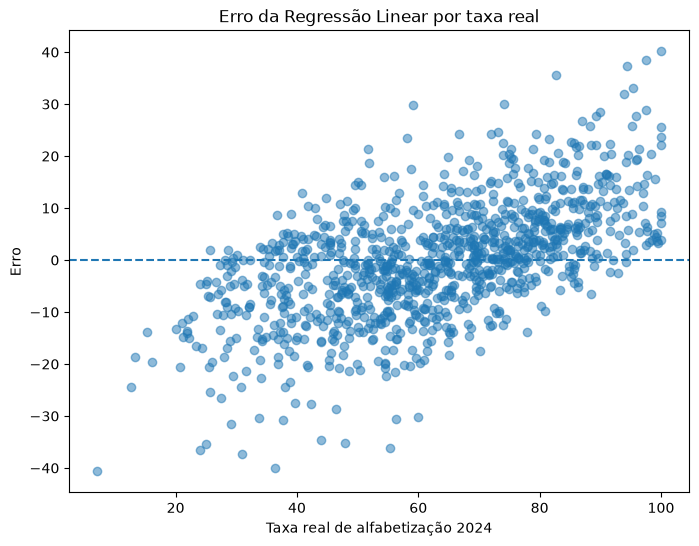

In [29]:
plt.figure(figsize=(8, 6))

plt.scatter(
    avaliacao["real"],
    avaliacao["erro"],
    alpha=0.5
)

plt.axhline(
    0,
    linestyle="--"
)

plt.xlabel("Taxa real de alfabetização 2024")
plt.ylabel("Erro")
plt.title("Erro da Regressão Linear por taxa real")

plt.show()

In [63]:
print(df.shape)
print(df.columns.tolist())
print(df[[
    "taxa_alfabetizacao_2023",
    "percentual_participacao_2023",
    "meta_alfabetizacao_2024",
    "taxa_alfabetizacao_2024",
    "UF",
    "Capital"
]].describe(include="all"))

(5352, 11)
['id_municipio', 'Municipio', 'UF', 'Capital', 'taxa_alfabetizacao_2023', 'percentual_participacao_2023', 'meta_alfabetizacao_2024', 'taxa_alfabetizacao_2024', 'Regiao', 'gap_meta_2024', 'target_atingiu_meta_2024']
        taxa_alfabetizacao_2023  percentual_participacao_2023  \
count               5232.000000                   5232.000000   
unique                      NaN                           NaN   
top                         NaN                           NaN   
freq                        NaN                           NaN   
mean                  60.478631                     89.814413   
std                   19.723480                      6.185810   
min                    4.400000                     70.000000   
25%                   46.800000                     86.140000   
50%                   60.950000                     90.560000   
75%                   75.125000                     94.440000   
max                  100.000000                    100.0000